In [ ]:
# 训练曲线检查 — 读取 train.log 查看 RL 训练过程

import matplotlib.pyplot as plt
import re
import numpy as np

# 修改此处路径，指向你要查看的 train.log
LOG_FILE = r"run/RL/train.log"
SMOOTH_RANGE = 10  # 平滑窗口大小

# Windows 中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def smooth_list(l, smooth_range=10):
    """滑动窗口平滑"""
    if len(l) < smooth_range:
        return l
    new_list = []
    for i in range(smooth_range - 1, len(l)):
        new_list.append(sum(l[i - smooth_range + 1 : i + 1]) / smooth_range)
    return new_list


def extract_cum_rewards(file_path):
    """从 train.log 中提取每 episode 的 cum reward"""
    values = []
    pattern = re.compile(r'cum reward\s*=\s*(-?\d+\.?\d*)')
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                values.append(float(match.group(1)))
    return values


def extract_episode_info(file_path):
    """提取 episode 编号和日期"""
    episodes = []
    pattern = re.compile(r'训练 Episode (\d+).*日期: (\d{4}-\d{2}-\d{2})')
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                episodes.append((int(match.group(1)), match.group(2)))
    return episodes

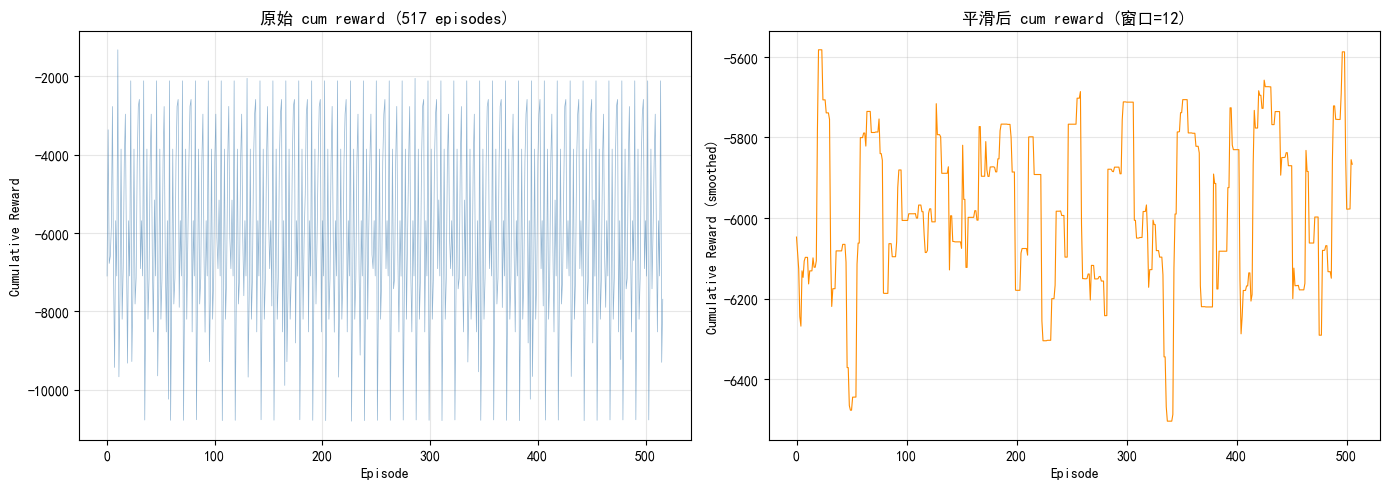

In [39]:
# 读取并解析日志

LOG_FILE = r"run/DispatchAwareRL/train.log"  # 修改为你的日志路径
SMOOTH_RANGE = 12  # 平滑窗口大小
rewards = extract_cum_rewards(LOG_FILE)
episodes = extract_episode_info(LOG_FILE)

# 绘制原始曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：原始值
axes[0].plot(rewards, linewidth=0.5, color='steelblue', alpha=0.6)
axes[0].set_title(f"原始 cum reward ({len(rewards)} episodes)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].grid(alpha=0.3)

# 右图：平滑后
smoothed = smooth_list(rewards, SMOOTH_RANGE)
axes[1].plot(smoothed, linewidth=0.8, color='darkorange')
axes[1].set_title(f"平滑后 cum reward (窗口={SMOOTH_RANGE})")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Cumulative Reward (smoothed)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

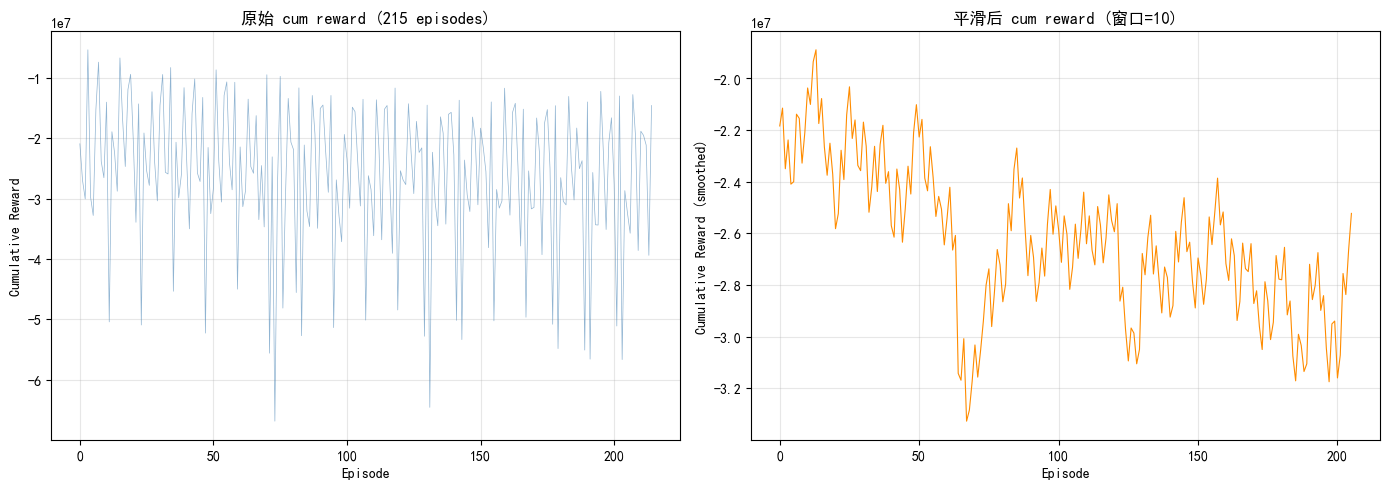

In [4]:
# 绘制原始曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：原始值
axes[0].plot(rewards, linewidth=0.5, color='steelblue', alpha=0.6)
axes[0].set_title(f"原始 cum reward ({len(rewards)} episodes)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].grid(alpha=0.3)

# 右图：平滑后
smoothed = smooth_list(rewards, SMOOTH_RANGE)
axes[1].plot(smoothed, linewidth=0.8, color='darkorange')
axes[1].set_title(f"平滑后 cum reward (窗口={SMOOTH_RANGE})")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Cumulative Reward (smoothed)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 双方法对比（如果两个文件夹都有 train.log）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = [
    ("run/RL/train.log", "RL", "steelblue"),
    ("run/DispatchAwareRL/train.log", "DispatchAwareRL", "darkorange"),
]

for filepath, label, color in methods:
    if os.path.exists(filepath):
        r = extract_cum_rewards(filepath)
        if r:
            s = smooth_list(r, SMOOTH_RANGE)
            axes[0].plot(r, linewidth=0.3, alpha=0.4, color=color)
            axes[1].plot(s, linewidth=0.8, label=label, color=color)
    else:
        print(f"[跳过] 文件不存在: {filepath}")

axes[0].set_title("原始值对比")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cum Reward")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"平滑后对比 (窗口={SMOOTH_RANGE})")
axes[1].set_xlabel("Episode")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()